# FESTO servo valve — supply characteristic

Supply pressure mapping: upstream = `supply_pressure` (AI ch6), downstream = `pam_valve_pressure` (AI ch1).

In [8]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt

ANALYSIS_DIR = Path.cwd()
if not (ANALYSIS_DIR / 'sweep_common.py').exists():
    ANALYSIS_DIR = Path('valve_sweep/analysis')
sys.path.insert(0, str(ANALYSIS_DIR.resolve()))

from sweep_common import (
    add_effective_area, load_config, load_sweep_bag, summarize_steps,
)

In [9]:
# Point this to a rosbag directory or directly to its .mcap file.
BAG_PATH = Path('~/koni_log/sweep_high_20260721_142237_340').expanduser()
CONFIG_PATH = ANALYSIS_DIR / 'calibration.yaml'

config = load_config(CONFIG_PATH)
samples = load_sweep_bag(BAG_PATH, config)
summary = summarize_steps(samples, config['analysis']['tail_duration_s'])
result = add_effective_area(summary, 'supply', config)
print(f'{len(samples):,} AI samples, {len(result)} voltage steps')

4,801 AI samples, 18 voltage steps


In [10]:
columns = [
    'step_index', 'command_voltage_v', 'sample_count',
    'flow_l_min_anr', 'flow_std_l_min',
    'upstream_pressure_kpa_g', 'downstream_pressure_kpa_g',
    'pressure_ratio', 'flow_factor_phi', 'mass_flow_kg_s',
    'effective_area_mm2', 'flow_direction_ok',
    'valid_pressure_ratio', 'flow_near_full_scale',
]
result[columns].round(6)

,step_index,command_voltage_v,sample_count,flow_l_min_anr,flow_std_l_min,upstream_pressure_kpa_g,downstream_pressure_kpa_g,pressure_ratio,flow_factor_phi,mass_flow_kg_s,effective_area_mm2,flow_direction_ok,valid_pressure_ratio,flow_near_full_scale
0,0,5.0,51,4.058157,0.182917,340.324305,4.846988,0.240399,1.000000,0.000081,0.078122,True,True,False
1,1,5.1,51,4.274775,0.266168,340.271948,4.846988,0.240427,1.000000,0.000086,0.082302,True,True,False
2,2,5.2,50,4.548717,0.193698,340.205853,4.833555,0.240433,1.000000,0.000091,0.087589,True,True,False
3,3,5.3,50,4.779429,0.229515,340.199752,4.940368,0.240678,1.000000,0.000096,0.092033,True,True,False
4,4,5.4,51,5.040708,0.224247,340.192660,4.941235,0.240684,1.000000,0.000101,0.097065,True,True,False
5,5,5.5,50,5.143200,0.391114,340.211958,4.931211,0.240651,1.000000,0.000103,0.099035,True,True,False
6,6,5.6,50,5.774321,0.714061,340.167708,5.016666,0.240868,1.000000,0.000116,0.111198,True,True,False
7,7,5.7,51,6.095081,1.108949,340.162743,5.059422,0.240968,1.000000,0.000122,0.117377,True,True,False
8,8,5.8,51,6.714417,0.646164,340.265970,5.093834,0.240990,1.000000,0.000135,0.129273,True,True,False
9,9,5.9,50,7.422906,0.957243,340.256214,5.201303,0.241238,1.000000,0.000149,0.142917,True,True,False


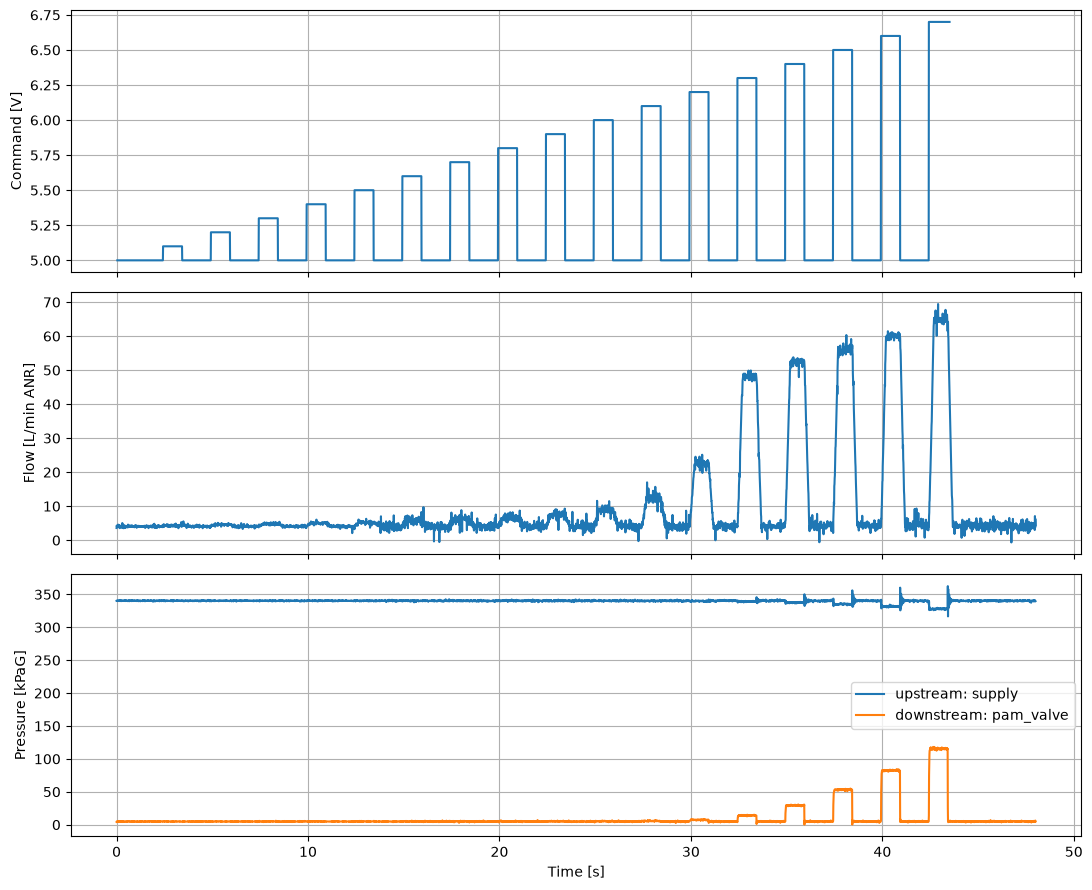

In [11]:
fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)
axes[0].plot(samples['time_s'], samples['command_voltage_v'])
axes[0].set_ylabel('Command [V]')
axes[1].plot(samples['time_s'], samples['flow_l_min_anr'])
axes[1].set_ylabel('Flow [L/min ANR]')
axes[2].plot(samples['time_s'], samples['supply_pressure_kpa_g'], label='upstream: supply')
axes[2].plot(samples['time_s'], samples['pam_valve_pressure_kpa_g'], label='downstream: pam_valve')
axes[2].set_ylabel('Pressure [kPaG]')
axes[2].set_xlabel('Time [s]')
axes[2].legend()
for axis in axes:
    axis.grid(True)
fig.tight_layout()

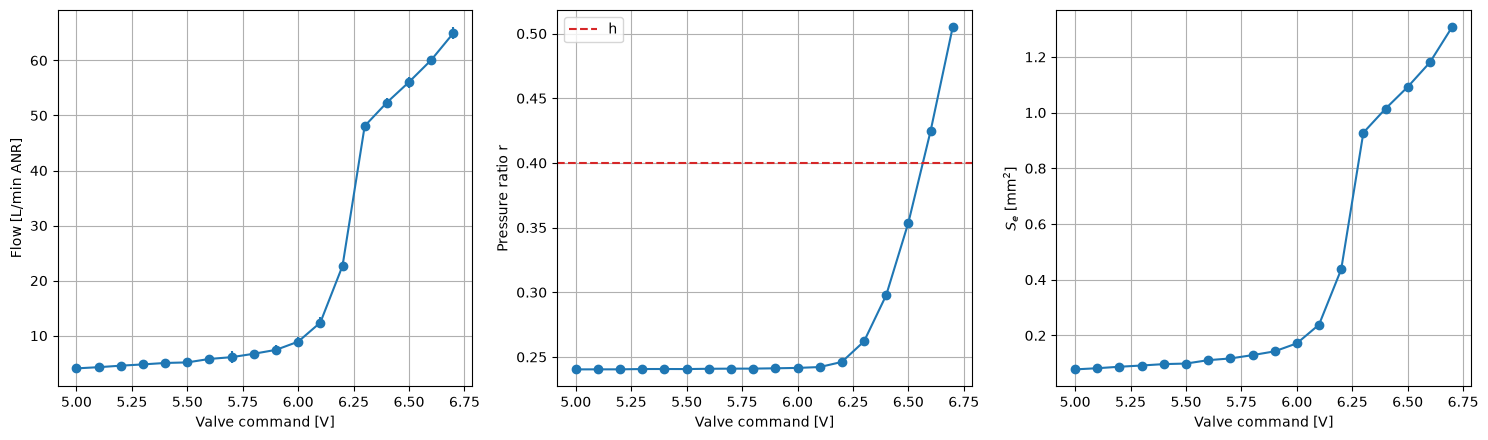

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
axes[0].errorbar(result['command_voltage_v'], result['flow_l_min_anr'], yerr=result['flow_std_l_min'], marker='o')
axes[0].set_ylabel('Flow [L/min ANR]')
axes[1].plot(result['command_voltage_v'], result['pressure_ratio'], marker='o')
axes[1].axhline(config['model']['critical_pressure_ratio'], color='tab:red', linestyle='--', label='h')
axes[1].set_ylabel('Pressure ratio r')
axes[1].legend()
axes[2].plot(result['command_voltage_v'], result['effective_area_mm2'], marker='o')
axes[2].set_ylabel(r'$S_e$ [mm$^2$]')
for axis in axes:
    axis.set_xlabel('Valve command [V]')
    axis.grid(True)
fig.tight_layout()

In [13]:
problems = result.loc[
    (~result['flow_direction_ok'])
    | (~result['valid_pressure_ratio'])
    | result['flow_near_full_scale']
]
if problems.empty:
    print('No direction, pressure-ratio, or flow-range warnings.')
else:
    display(problems[columns])

No direction, pressure-ratio, or flow-range warnings.


In [14]:
# Optional CSV export
# output_path = BAG_PATH.with_name(BAG_PATH.name + '_supply_analysis.csv')
# result.to_csv(output_path, index=False)
# output_path